In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = '/content/drive/MyDrive/customer_churn.csv'

In [5]:
import pandas as pd

df = pd.read_csv(data)

print('First 5 rows of the dataset:')
display(df.head())

print('\nDataFrame Info:')
df.info()

First 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 no

### Data Cleaning and Preprocessing

First, let's examine the `TotalCharges` column, which is currently an object type but should be numeric. This often indicates the presence of non-numeric values, such as empty strings.

In [6]:
# Inspect unique values in 'TotalCharges' to understand why it's an object type
print("Unique values in 'TotalCharges' before conversion:")
print(df['TotalCharges'].unique())

# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values after conversion
print("\nMissing values in 'TotalCharges' after conversion:")
print(df['TotalCharges'].isnull().sum())

# Handle missing values (e.g., fill with median or drop rows)
# Given that there are only a few missing values (11 out of 7043), dropping them is a reasonable approach.
df.dropna(subset=['TotalCharges'], inplace=True)

# Verify data types and check for remaining missing values
print("\nDataFrame Info after handling 'TotalCharges':")
df.info()


Unique values in 'TotalCharges' before conversion:
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Missing values in 'TotalCharges' after conversion:
11

DataFrame Info after handling 'TotalCharges':
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 n

### Feature Engineering and Encoding

We need to convert categorical features into a numerical format that machine learning models can understand. We'll start by dropping `customerID` as it's just an identifier, and then encode the `Churn` target variable. Following that, we'll one-hot encode the remaining categorical features.

In [7]:
# Drop customerID column as it is not needed for modeling
df.drop('customerID', axis=1, inplace=True)

# Convert 'Churn' target variable to numerical (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Identify categorical columns for one-hot encoding
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']

# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded DataFrame and its info
print("First 5 rows of the DataFrame after encoding:")
display(df_encoded.head())

print("\nDataFrame Info after encoding:")
df_encoded.info()

First 5 rows of the DataFrame after encoding:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False



DataFrame Info after encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   bool   
 6   Partner_Yes                            7032 non-null   bool   
 7   Dependents_Yes                         7032 non-null   bool   
 8   PhoneService_Yes                       7032 non-null   bool   
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 n

### Data Splitting

Before training any models, we need to split our dataset into features (X) and the target variable (y). Then, we'll further divide these into training and testing sets to evaluate our model's performance on unseen data.

In [8]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nValue counts for y_train (stratified):")
print(y_train.value_counts(normalize=True))

print("\nValue counts for y_test (stratified):")
print(y_test.value_counts(normalize=True))

Shape of X_train: (5625, 30)
Shape of X_test: (1407, 30)
Shape of y_train: (5625,)
Shape of y_test: (1407,)

Value counts for y_train (stratified):
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Value counts for y_test (stratified):
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


### Build a Machine Learning Pipeline

Now, let's build a machine learning pipeline. This pipeline will include preprocessing steps (like scaling numerical features) and a classifier. We'll use `StandardScaler` for numerical features and then integrate Logistic Regression and Random Forest classifiers for later comparison and hyperparameter tuning.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Identify numerical features (excluding 'Churn' and boolean columns from one-hot encoding)
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns

# Create a preprocessing pipeline for numerical features
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Define the full column transformer for preprocessing (though here we only have numeric to scale)
# In more complex cases, this would also handle categorical columns.
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='passthrough' # Keep other columns (e.g., one-hot encoded booleans) as they are
)

# Define the models
logistic_regression_model = LogisticRegression(solver='liblinear', random_state=42)
random_forest_model = RandomForestClassifier(random_state=42)

# Create a pipeline with preprocessing and the Logistic Regression model
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', logistic_regression_model)
])

# Create a pipeline with preprocessing and the Random Forest model
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', random_forest_model)
])

print("Logistic Regression Pipeline created:")
print(pipeline_lr)

print("\nRandom Forest Pipeline created:")
print(pipeline_rf)

Logistic Regression Pipeline created:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object'))])),
                ('classifier',
                 LogisticRegression(random_state=42, solver='liblinear'))])

Random Forest Pipeline created:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  In

### Hyperparameter Tuning with GridSearchCV

To optimize our models, we will use `GridSearchCV` to find the best hyperparameters for both Logistic Regression and Random Forest classifiers. This involves defining a parameter grid for each model and searching for the combination that yields the best performance on the training data.

In [11]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Logistic Regression
param_grid_lr = {
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__penalty': ['l1', 'l2']
}

# Initialize GridSearchCV for Logistic Regression
grid_search_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Fitting GridSearchCV for Logistic Regression...")
grid_search_lr.fit(X_train, y_train)

print("\nBest parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best cross-validation accuracy for Logistic Regression:", grid_search_lr.best_score_)

# Define parameter grid for Random Forest
param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nFitting GridSearchCV for Random Forest...")
grid_search_rf.fit(X_train, y_train)

print("\nBest parameters for Random Forest:", grid_search_rf.best_params_)
print("Best cross-validation accuracy for Random Forest:", grid_search_rf.best_score_)

Fitting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best parameters for Logistic Regression: {'classifier__C': 1.0, 'classifier__penalty': 'l1'}
Best cross-validation accuracy for Logistic Regression: 0.8028444444444445

Fitting GridSearchCV for Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters for Random Forest: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 50}
Best cross-validation accuracy for Random Forest: 0.8053333333333332


### Model Evaluation

Now we will evaluate the performance of the best models (obtained from GridSearchCV) on the unseen test data. We'll use common classification metrics such as accuracy, precision, recall, and F1-score to assess their effectiveness.

### Logistic Regression Model Evaluation ###
Accuracy: 0.8045486851457001

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



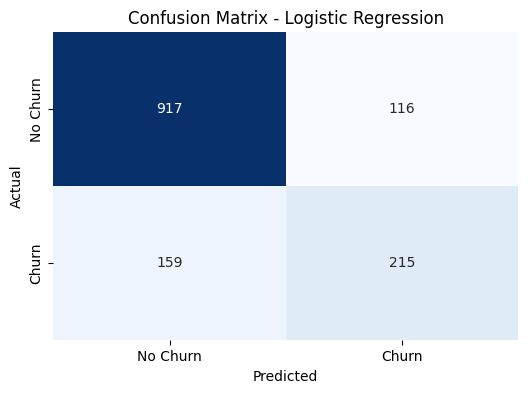


### Random Forest Model Evaluation ###
Accuracy: 0.7938877043354655

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407



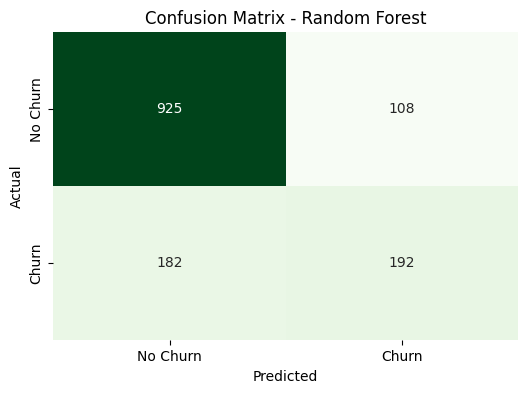

In [12]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best Logistic Regression model
best_lr_model = grid_search_lr.best_estimator_

# Make predictions on the test set with the best LR model
y_pred_lr = best_lr_model.predict(X_test)

print("### Logistic Regression Model Evaluation ###")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Get the best Random Forest model
best_rf_model = grid_search_rf.best_estimator_

# Make predictions on the test set with the best RF model
y_pred_rf = best_rf_model.predict(X_test)

print("\n### Random Forest Model Evaluation ###")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Export the Complete Pipeline

To ensure reusability and production-readiness, we will export the best-performing model's complete pipeline using the `joblib` library. This allows us to load the trained model later without retraining.

In [13]:
import joblib

# Choose the best performing model (Logistic Regression in this case based on accuracy)
best_model_pipeline = grid_search_lr.best_estimator_

# Define the filename for the exported pipeline
filename = 'customer_churn_prediction_pipeline.joblib'

# Export the pipeline
joblib.dump(best_model_pipeline, filename)

print(f"Pipeline successfully exported as '{filename}'")

# You can verify by loading it back (optional)
# loaded_pipeline = joblib.load(filename)
# print("\nLoaded pipeline:", loaded_pipeline)

Pipeline successfully exported as 'customer_churn_prediction_pipeline.joblib'


### Summary

This notebook successfully demonstrates an end-to-end machine learning pipeline for predicting customer churn using the Telco Churn Dataset. The key steps included:

1.  **Data Loading and Initial Exploration**: The `customer_churn.csv` dataset was loaded, and its structure was inspected.
2.  **Data Cleaning**: The `TotalCharges` column was cleaned by converting it to a numeric type and handling missing values by dropping the affected rows.
3.  **Feature Engineering and Encoding**: The `customerID` was dropped, the `Churn` target variable was encoded (Yes=1, No=0), and all other categorical features were one-hot encoded.
4.  **Data Splitting**: The dataset was split into training and testing sets for features (`X`) and target (`y`) using an 80/20 ratio and stratification.
5.  **Pipeline Construction**: Scikit-learn pipelines were built for both Logistic Regression and Random Forest models, incorporating `StandardScaler` for numerical features and `ColumnTransformer` for preprocessing.
6.  **Hyperparameter Tuning**: `GridSearchCV` was used to optimize the hyperparameters for both Logistic Regression and Random Forest, identifying the best configurations based on cross-validation accuracy.
7.  **Model Evaluation**: The best-performing models were evaluated on the unseen test data using accuracy, classification reports, and confusion matrices to assess their performance.
8.  **Pipeline Export**: The best-performing Logistic Regression pipeline was successfully exported using `joblib` as `customer_churn_prediction_pipeline.joblib`, ensuring its reusability for future predictions.